## Free Fall as a System of First-Order ODEs

The motion of a particle under gravity is described by the second-order differential equation:

$$
\frac{d^2 x}{dt^2} = -g
$$

where:
-  x(t)  is the position  
-  g is the acceleration due to gravity  



The numerical solvers  Euler and Runge–Kutta methods are designed to solve first-order equations of the form:

$$
\frac{dy}{dt} = f(t, y)
$$

So to use these methods for this problem , we need to convert the second-order equation into a system of first-order equations.

We know that 

$$
\frac{dx}{dt} = v
\frac{dv}{dt} = -g
$$

So we can define a vector

$$
y =
\begin{bmatrix}
x \\
v
\end{bmatrix}
$$

So the system becomes,

$$
\frac{dy}{dt} =
\begin{bmatrix}
v \\
-g
\end{bmatrix}
$$

Now we can  use standard ODE solvers by making position and velocity as components of a single vector.




In [1]:
import sys
import os

sys.path.append("../src")
from euler import EulerODE
from rkmethods import rk4
from rkmethods import rk5

import numpy as np
import matplotlib.pyplot as plt

# freefall function

def f(t,y):

    # x : position
    # v : velocity
    # g : acceleration due to gravity
    # returns dx/dt and dv/dt

    x,v = y  # takes y = [x,v] 

    return np.array([v,-g])

g = 9.81
x = 0 # initial position
v = 14 # initial velocity
y0 = np.array([x, v])  #  starting point
t0 = 0
h = 0.01
n = 500

t_1, y_1 = EulerODE(f, t0, y0, n, h)
t_2, y_2 = rk4(f, t0, y0, n, h)
t_3, y_3 = rk5(f, t0, y0, n, h)

# now the solvers return us with the vector y with x and v 

x1,v1 = y_1[:,0],y_1[:,1]  # taking values of x and v using ':'  take all rows from colomn 0 and 1
x2,v2 = y_2[:,0],y_2[:,1] 
x3,v3 = y_3[:,0],y_3[:,1] 



Now we can compare this with exact value.

The analytical solution is

$$
x(t) = x_0 + v_0 t - \frac{1}{2} g t^2



v(t) = v_0 - g t
$$


In [2]:
t = t_1  # same grid

x_exact = x + v*t - 0.5*g*t**2
v_exact = v - g*t

We can plot the position vs time graph for free fall

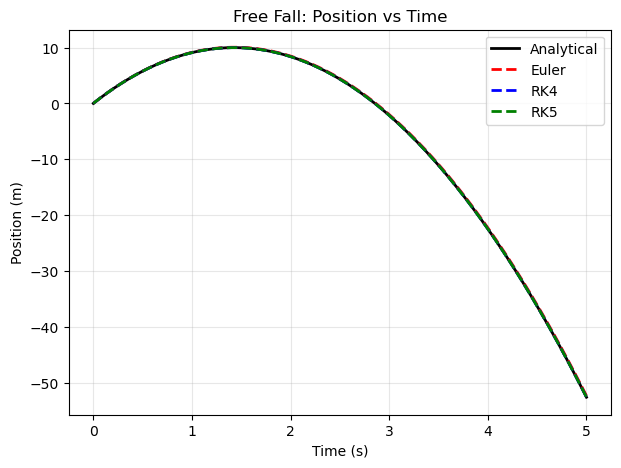

In [3]:
plt.figure(figsize=(7,5))

plt.plot(t, x_exact,color='black',linewidth=2,label='Analytical')

plt.plot(t_1, x1,color='red',linestyle='--',linewidth=2,label='Euler')

plt.plot(t_2, x2,color='blue',linestyle='--',linewidth=2,label='RK4')

plt.plot(t_3, x3,color='green',linestyle='--',linewidth=2,label='RK5')

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Free Fall: Position vs Time")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

We can also plot Position vs velocity (phase plot)

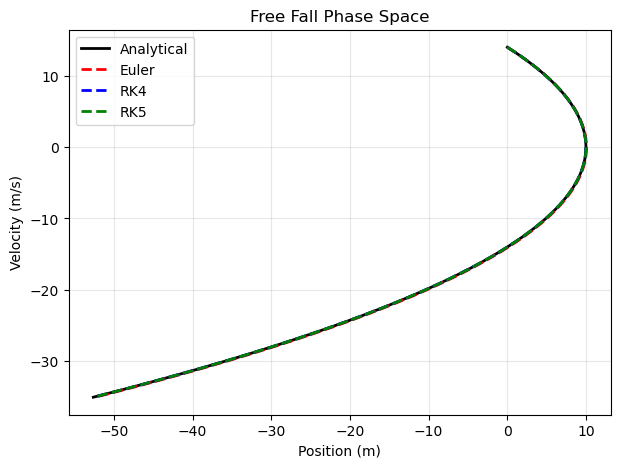

In [4]:
plt.figure(figsize=(7,5))

plt.plot(x_exact, v_exact,color='black',linewidth=2,label='Analytical')

plt.plot(x1, v1,color='red',linestyle='--',linewidth=2,label='Euler')

plt.plot(x2, v2,color='blue',linestyle='--',linewidth=2,label='RK4')

plt.plot(x3, v3,color='green',linestyle='--',linewidth=2,label='RK5')

plt.xlabel("Position (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Free Fall Phase Space")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Still all the methods are alinged. So now we can try to find the error in this calculation.

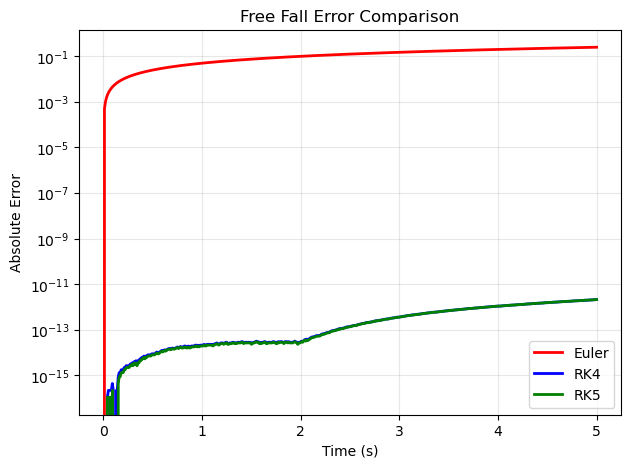

In [5]:
# Absolute errors
error_euler = np.abs(x1 - x_exact)
error_rk4   = np.abs(x2 - x_exact)
error_rk5   = np.abs(x3 - x_exact)

plt.figure(figsize=(7,5))

plt.plot(t, error_euler,color='red',linewidth=2,label='Euler')

plt.plot(t, error_rk4,color='blue',linewidth=2,label='RK4')

plt.plot(t, error_rk5,color='green',linewidth=2,label='RK5')

plt.yscale("log")

plt.xlabel("Time (s)")
plt.ylabel("Absolute Error")
plt.title("Free Fall Error Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

The error is low in RK methods compared to Euler in freefall calculations.

We have not yet considered air resistance in our calculations.

## Free Fall with Air Resistance

In realistic scenarios, an object moving through a fluid (such as air) experiences a resistive force known as drag. This force opposes the motion and modifies the equations of motion.


The general equation for motion under gravity with drag is:

$$
\frac{d^2 x}{dt^2} = -g + \frac{F_d}{m}
$$

where:
- g is the acceleration due to gravity  
- F_d  is the drag force  
- m  is the mass of the object  




For low velocities, drag is often modeled as proportional to velocity:

$$
F_d = -k v
$$

Substituting into the equation of motion:

$$
\frac{dv}{dt} = -g - \frac{k}{m} v
$$

The system of first-order equations becomes:

$$
\frac{dx}{dt} = v
\frac{dv}{dt} = -g - \frac{k}{m} v
$$



For higher velocities, drag is better approximated as proportional to the square of velocity:

$$
F_d = -k v |v|
$$

This ensures that the drag force always opposes the direction of motion.

The equation of motion becomes:

$$
\frac{dv}{dt} = -g - \frac{k}{m} v |v|
$$

The corresponding system is:

$$
\frac{dx}{dt} = v

\frac{dv}{dt} = -g - \frac{k}{m} v |v|
$$



### Terminal Velocity

Terminal velocity is the constant velocity reached when the drag force balances gravity, causing acceleration to become zero and preventing further increase in speed
In both models, the object eventually reaches a constant velocity when acceleration becomes zero:

$$
\frac{dv}{dt} = 0
$$

#### Linear Drag:

$$
v_{\text{terminal}} = -\frac{mg}{k}
$$

#### Quadratic Drag:

$$
v_{\text{terminal}} = -\sqrt{\frac{mg}{k}}
$$


### Physical Basis of Drag Models

The drag models used here are standard approximations from fluid dynamics. 

For low-speed motion in smooth (laminar) flow regimes, the resistive force is proportional to velocity, leading to the linear drag model. This is consistent with Stokes' law for small particles moving through a viscous medium.

At higher velocities, the flow becomes more complex and turbulent, and the drag force is better approximated as proportional to the square of velocity. This leads to the quadratic drag model, which provides a more realistic description of objects moving through air.

The choice between these models depends on the physical conditions, particularly the flow regime around the object.



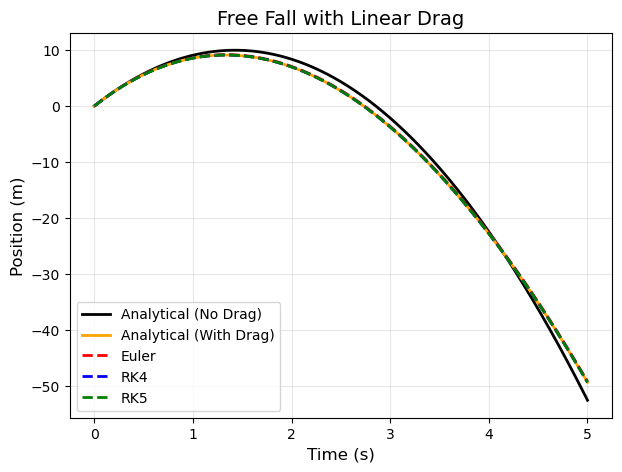

In [6]:
# Function with linear air resistance 

def f(t,y):

    # x : position
    # v : velocity
    # g : acceleration due to gravity
    # returns dx/dt and dv/dt
    # k : drag constant
    x,v = y  # takes y = [x,v] 

    return np.array([v,-g-k*v]) # varying k on our own and taking the mass m = 1 (or k = k/m as effective parameter)

g = 9.81
k = 0.1
x = 0.0 # initial position
v = 14.0 # initial velocity
y0 = np.array([x, v])  #  starting point
t0 = 0
h = 0.01
n = 500

t1, y1 = EulerODE(f, t0, y0, n, h)
t2, y2 = rk4(f, t0, y0, n, h)
t3, y3 = rk5(f, t0, y0, n, h)

x1,v1 = y1[:,0],y1[:,1] 
x2,v2 = y2[:,0],y2[:,1] 
x3,v3 = y3[:,0],y3[:,1] 


# exact position with drag 
t = t1
xexact = x - (g/k)*t + (1/k)*(v + g/k)*(1 - np.exp(-k*t))

x_exact = x + v*t - 0.5*g*t**2
v_exact = v - g*t

plt.figure(figsize=(7,5))

plt.plot(t1, x_exact,color='black',linewidth=2,label='Analytical (No Drag)')

plt.plot(t1, xexact,color='orange',linewidth=2,label='Analytical (With Drag)')

plt.plot(t1, x1,color='red',linestyle='--',linewidth=2,label='Euler')

plt.plot(t2, x2,color='blue',linestyle='--',linewidth=2,label='RK4')

plt.plot(t3, x3,color='green',linestyle='--',linewidth=2,label='RK5')

plt.xlabel("Time (s)",fontsize=12)
plt.ylabel("Position (m)",fontsize=12)
plt.title("Free Fall with Linear Drag",fontsize=14)

plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.savefig("../Images/freefallwithlineardrag.png", dpi=300, bbox_inches='tight')
plt.show()

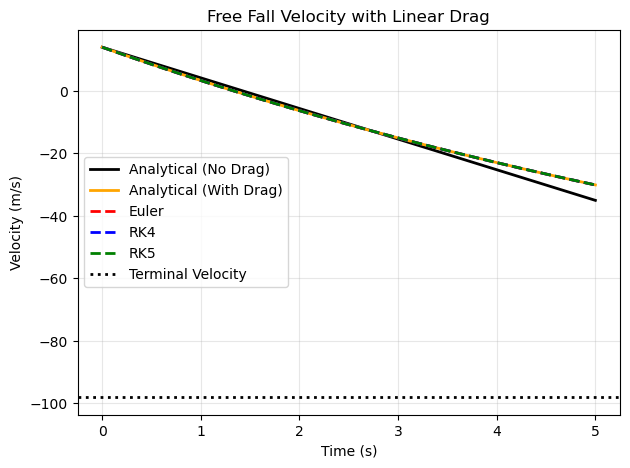

In [7]:
t = t2  # or any time array
v_exact = v - g*t
plt.figure(figsize=(7,5))

# Exact velocity with drag
vexact = -g/k + (v + g/k)*np.exp(-k*t)

plt.plot(t1, v_exact,color='black',linewidth=2,label='Analytical (No Drag)')

plt.plot(t1, vexact,color='orange',linewidth=2,label='Analytical (With Drag)')

plt.plot(t1, v1,color='red',linestyle='--',linewidth=2,label='Euler')

plt.plot(t2, v2,color='blue',linestyle='--',linewidth=2,label='RK4')

plt.plot(t3, v3,color='green',linestyle='--',linewidth=2,label='RK5')

# Terminal velocity
v_term = -g/k

plt.axhline(v_term,color='black',linestyle=':',linewidth=2,label='Terminal Velocity')

plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Free Fall Velocity with Linear Drag")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

All three numerical methods (Euler, RK4, and RK5) show excellent agreement with the analytical solution for free fall with linear drag when a sufficiently small step size is used.

Having validated the accuracy of the numerical solvers, we can now investigate how varying the drag coefficient k influences the dynamics of free fall. 

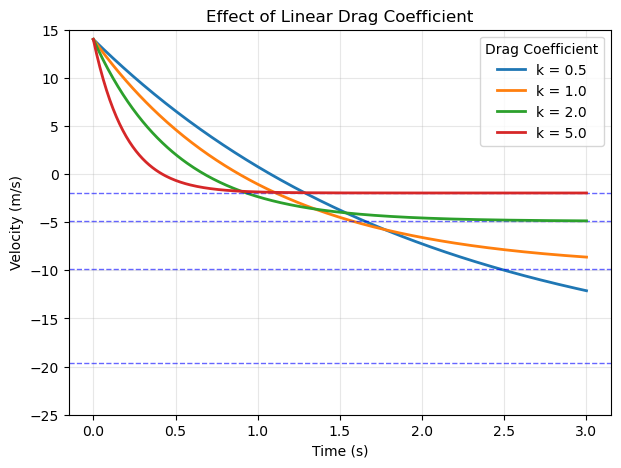

In [8]:
# varying k for its influene
g = 9.81
ks = [0.5, 1.0, 2.0, 5.0]
t_max = 3
h = 0.01
x = 0.0 # initial position
v = 14.0 # initial velocity
y0 = np.array([x, v])  #  starting point
t0 = 0
plt.figure(figsize=(7,5))

for k in ks:

    n = int(t_max / h)

    t, y = rk4(f, 0, y0, n, h)

    v = y[:,1]

    # Terminal velocity
    v_term = -g/k

    plt.axhline(v_term,linestyle='--',linewidth=1,alpha=0.6)

    plt.plot(t, v,linewidth=2,label=f"k = {k}")

plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Effect of Linear Drag Coefficient")

plt.ylim(-25, 15)

plt.legend(title="Drag Coefficient")
plt.grid(alpha=0.3)

plt.show()

We can see that increasing the drag coefficient leads to faster convergence to terminal velocity while reducing its magnitude. Stronger drag forces damp the motion more rapidly, causing the system to reach steady-state behavior sooner.

Lets now try quadratic too

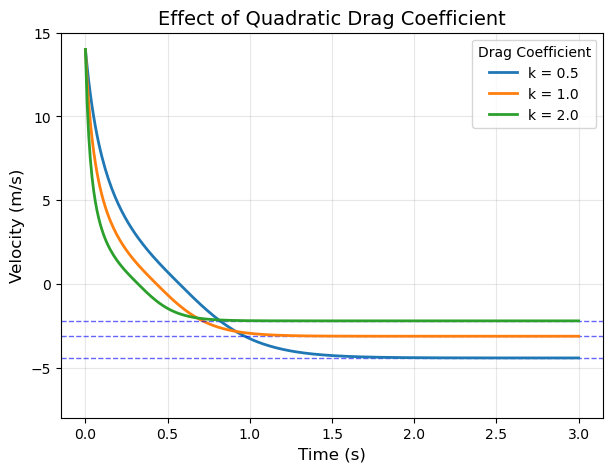

In [9]:
def f(t,y):

    # x : position
    # v : velocity
    # g : acceleration due to gravity
    # returns dx/dt and dv/dt

    x,v = y  # takes y = [x,v] 

    return np.array([v, -g - k*v*abs(v)])

ks = [0.5, 1.0, 2.0]
t_max = 3
g = 9.81
x = 0 # initial position
v = 14 # initial velocity
y0 = np.array([x, v])  #  starting point
t0 = 0
h = 0.01

plt.figure(figsize=(7,5))

for k in ks:

    n = int(t_max / h)

    t, y = rk4(f, 0, y0, n, h)

    v = y[:,1]

    # Terminal velocity for quadratic drag
    v_term = -np.sqrt(g/k)

    plt.axhline(v_term,linestyle='--',linewidth=1,alpha=0.6)

    plt.plot(t, v,linewidth=2,label=f"k = {k}")

plt.xlabel("Time (s)",fontsize=12)
plt.ylabel("Velocity (m/s)",fontsize=12)
plt.title("Effect of Quadratic Drag Coefficient",fontsize=14)

plt.ylim(-8, 15)

plt.legend(title="Drag Coefficient",fontsize=10)
plt.grid(alpha=0.3)
plt.savefig("../Images/effectofquadraticdragcoefficient.png", dpi=300, bbox_inches='tight')
plt.show()
    




In quadratic drag, the resistive force increases more rapidly with velocity compared to linear drag. As a result, the object experiences stronger initial damping and tends to approach terminal velocity more quickly. This makes quadratic drag a more realistic model for motion at higher speeds.

## Conclusion

Here  numerical methods including Euler, RK4, and RK5 were implemented  to solve ordinary differential equations arising in free fall problems. The methods were first validated against analytical solutions in the absence of drag and in the case of  drag, showing good agreement for sufficiently small step sizes.

The addition of  air resistance, the motion becomes different. In the linear drag model the velocity approaches a constant terminal value, while in the quadratic drag model,stronger velocity dependent damping leads to more realistic behaviour at larger speeds.

The effect of the drag coefficient on the system dynamics was investigated in the study, and it can be concluded that the bigger the drag coefficient, the smaller the magnitude of the terminal velocity and the faster the steady-state motion is achieved.